In [1]:
import numpy as np
import pandas as pd

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [2]:
items = pd.read_csv('items (1).csv')

q1 = pd.read_csv('quarter-1.csv')
q2 = pd.read_csv('quarter-2.csv')
q3 = pd.read_csv('quarter-3.csv')


### `Q:1-5`
1. You are given three quater files, your job is to append these three files and make a single dataframe.
2. Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
4. Find out items which has made most revenue in each quarter.
5. Find out avg order price of each quarter.

***Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.***

In [3]:
q2['item_price'] = (q2['item_price'].str.replace('$','').astype(float))*279.73

In [4]:
q1['item_price'] = (q1['item_price'].str.replace('$','').astype(float))*279.73

In [5]:
# 1. You are given three quater files, your job is to append these three files and make a single dataframe.
# Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
df1 = pd.concat([q1,q2,q3],keys=['Q1','Q2','Q3'])
df1.sample(5)

C:\Users\HP\AppData\Local\Temp\ipykernel_2816\1907010014.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df1 = pd.concat([q1,q2,q3],keys=['Q1','Q2','Q3'])


order_id quantity item_id choice_description_id  item_price
Q2 2148     1701        1      24                   162   3146.9625
   2250     1768        1       4                    51   2447.6375
Q1 1341     1089        1      26                     0    825.2035
Q2 1598     1254        1      12                    75    304.9057
   1595     1252        1       6                   829   3099.4084

In [6]:
# 3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
new_df = df1.reset_index().merge(items,on='item_id')

new_df.groupby(['level_0','item_name'],as_index=False)['quantity'].sum().sort_values(by='quantity',ascending=False).drop_duplicates(subset='level_0',keep='first')


,level_0,item_name,quantity
65,Q2,Chicken Bowl,394
17,Q1,Chicken Bowl,367


In [7]:
 # Find out items which has made most revenue in each quarter.
new_df.groupby(['level_0','item_name'],as_index=False)['item_price'].sum().sort_values(by='item_price',ascending=False).drop_duplicates(subset='level_0',keep='first')

,level_0,item_name,item_price
65,Q2,Chicken Bowl,1.067732e+06
17,Q1,Chicken Bowl,9.862497e+05


In [8]:
new_df['total_price'] = new_df['item_price']* new_df['quantity']
new_df

,level_0,level_1,order_id,quantity,item_id,choice_description_id,item_price,item_name,total_price
0,Q1,0,1,1,1,1,948.2847,Izze,948.2847
1,Q1,1,1,1,2,2,948.2847,Nantucket Nectar,948.2847
2,Q1,2,2,2,4,3,4749.8154,Chicken Bowl,9499.6308
3,Q1,3,4,1,7,6,2587.5025,Steak Soft Tacos,2587.5025
4,Q1,4,6,1,9,8,2447.6375,Chicken Crispy Tacos,2447.6375
...,...,...,...,...,...,...,...,...,...
4617,Q2,2342,1829,1,23,92,3146.9625,Veggie Burrito,3146.9625
4618,Q2,2343,1830,1,23,1043,3146.9625,Veggie Burrito,3146.9625
4619,Q2,2344,1832,1,10,116,2447.6375,Chicken Soft Tacos,2447.6375
4620,Q2,2345,1832,1,8,0,1244.7985,Chips and Guacamole,1244.7985


In [9]:
 # Find out items which has made most revenue in each quarter.
new_df.groupby(['level_0','item_name'],as_index=False)['total_price'].sum().sort_values(by='total_price',ascending=False).drop_duplicates(subset='level_0',keep='first')

,level_0,item_name,total_price
65,Q2,Chicken Bowl,1172698.0925
17,Q1,Chicken Bowl,1077626.2574


In [10]:
# 5. Find out avg order price of each quarter.


In [11]:
d=new_df.groupby(["level_0", "order_id"], as_index = False)['total_price'].sum()


In [12]:
new_df.groupby(["level_0", "order_id"], as_index = False)["total_price"].sum().groupby("level_0", as_index = False)["total_price"].mean()

,level_0,total_price
0,Q1,3862.928047
1,Q2,3714.766237


In [13]:
new_df

,level_0,level_1,order_id,quantity,item_id,choice_description_id,item_price,item_name,total_price
0,Q1,0,1,1,1,1,948.2847,Izze,948.2847
1,Q1,1,1,1,2,2,948.2847,Nantucket Nectar,948.2847
2,Q1,2,2,2,4,3,4749.8154,Chicken Bowl,9499.6308
3,Q1,3,4,1,7,6,2587.5025,Steak Soft Tacos,2587.5025
4,Q1,4,6,1,9,8,2447.6375,Chicken Crispy Tacos,2447.6375
...,...,...,...,...,...,...,...,...,...
4617,Q2,2342,1829,1,23,92,3146.9625,Veggie Burrito,3146.9625
4618,Q2,2343,1830,1,23,1043,3146.9625,Veggie Burrito,3146.9625
4619,Q2,2344,1832,1,10,116,2447.6375,Chicken Soft Tacos,2447.6375
4620,Q2,2345,1832,1,8,0,1244.7985,Chips and Guacamole,1244.7985


In [14]:
avg_order_price = (
    new_df
    .groupby('level_0')
    .agg(
        total_revenue=('total_price', 'sum'),
        total_orders=('order_id', 'nunique')
    )
)

avg_order_price['avg_order_price'] = (
    avg_order_price['total_revenue'] / avg_order_price['total_orders']
)

avg_order_price.reset_index()


,level_0,total_revenue,total_orders,avg_order_price
0,Q1,5581931.0283,1445,3862.928047
1,Q2,5393840.5763,1452,3714.766237


In [15]:
# step 1: order level total
order_total = (
    new_df
    .groupby(['level_0', 'order_id'], as_index=False)['total_price']
    .sum()
)

# step 2: average order price per quarter
avg_order_price = (
    order_total
    .groupby('level_0')['total_price']
    .mean()
    .reset_index(name='avg_order_price')
)
order_total.groupby('level_0')['total_price'].mean()

level_0
Q1    3862.928047
Q2    3714.766237
Name: total_price, dtype: object

### `Q-6` From the IPL wala dataset you have to find the Purple cap holder each season.

*Note: Bowler with most no wickets in a season gets purple cap. If more than one bowler have same no of wickets in the season, one with least ecomnomy among them is purple cap holder.*

Bowler's Economy = runs-conceded per six balls

<Axes: xlabel='bowler'>

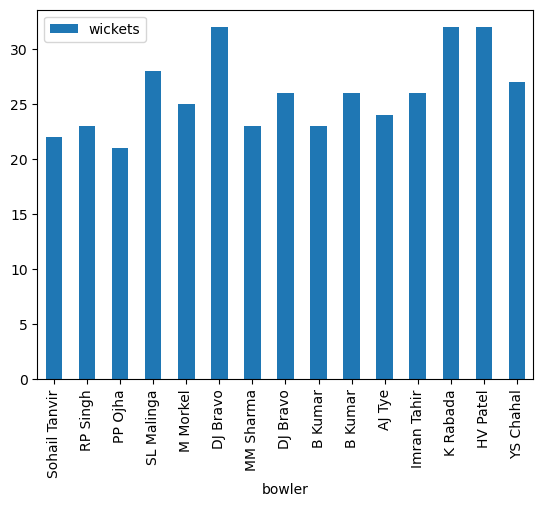

In [16]:
balls = pd.read_csv('ipl_deliveries.csv')
matches = pd.read_csv('IPL_Matches_2008_2022.csv')
seasondf = balls.merge(matches[['ID','Season']],on='ID')
seasondf['wickets'] = seasondf.kind.apply(lambda x: 1 if x in ["caught", 'caught and bowled', 'bowled', 'stumped','lbw', 'hit wicket'] else 0)
seasondf['Boller_Runs'] = seasondf.extra_type.apply(lambda x: 0 if x in ['legbyes', 'byes'] else 1) * seasondf['total_run']

seasondf['IsLegalBalls'] = seasondf.extra_type.apply(lambda x: 0 if x in ["wides", "noballs"] else 1)

pchdf = seasondf.groupby(['Season','bowler'],as_index = False)[['wickets','Boller_Runs','IsLegalBalls']].sum()
pchdf['Economy'] = pchdf['Boller_Runs'] / (pchdf['IsLegalBalls'] / 6)
pchdf = pchdf.sort_values(by=['Season', 'wickets'],ascending=[True,False]).drop_duplicates(subset='Season',keep='first')
pchdf.plot(x='bowler', y='wickets', kind='bar')


### `Q-7:` Best bowler in death overs.
*Note: Have taken most no of wickets in case of tie with least economy*

Death Overs - [16-20]

In [17]:
death_overs = seasondf[seasondf['overs'] >=15]
pchdf = death_overs.groupby('bowler',as_index=False)[['wickets','Boller_Runs','IsLegalBalls']].sum()
pchdf['Economy'] = pchdf['Boller_Runs'] / (pchdf['IsLegalBalls'] / 6)
pchdf = pchdf.sort_values(by=['wickets','Economy'],ascending=[False,True])
pchdf.head()


,bowler,wickets,Boller_Runs,IsLegalBalls,Economy
91,DJ Bravo,115,2161,1385,9.361733
331,SL Malinga,108,1464,1117,7.863921
53,B Kumar,90,1752,1173,8.961637
148,JJ Bumrah,80,1614,1146,8.450262
339,SP Narine,67,1164,949,7.359326


### `Q-8` Batsman record season wise

Make a function which takes a input `batsman_name` and it returns a dataframe.
Columns of the data frame are - `['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']`.
* In result make `Season` column as index.

* Avg - total_runs/ no of time got out. - player_out column will help.
* StrikeRate -(total_runs/ balls faced) * 100- wides are not included in batsman ball faced counts. No balls are included. -> Extra_type column will help
* Batsman Can score runs on No Balls.
* Batsman can get out on No Ball or Wides. And even while being on non-striker. Keep these things in mind before masking.

In [18]:
# code here
batterdf = seasondf.copy()
batterdf["IsBatsmanBall"] = batterdf["extra_type"].apply(lambda x: 1 if x != "wides" else 0)

def bat_record_season(batsman):
    bdf = batterdf[batterdf.batter == batsman].copy()
    bdf["IsBatsmanOut"] = bdf.batter == bdf.player_out
    df = bdf.groupby(["Season", "ID"], as_index = False)[["batsman_run", "IsBatsmanBall", "IsBatsmanOut"]].sum()
    innings = df.groupby("Season").ID.count()
    df = df.groupby("Season").agg(
    {
        "batsman_run":["sum", "max"],
        "IsBatsmanBall": "sum",
        "IsBatsmanOut": "sum"
    })
    df["Innings"]= innings
    df["TotalRuns"] = df[("batsman_run", "sum")]
    df["Avg"] = df["TotalRuns"] / df[("IsBatsmanOut", "sum")]
    df["HighestScore"] = df[("batsman_run", "max")]
    df["StrikeRate"] = df["TotalRuns"] / df[("IsBatsmanBall", "sum")] * 100
    return df.drop(columns = ["batsman_run", "IsBatsmanBall", "IsBatsmanOut"])
bat_record_season("V Kohli")

,Innings,TotalRuns,Avg,HighestScore,StrikeRate
,,,,,
Season,,,,,
2007/08,12,165,15.000000,38,105.095541
2009,13,246,22.363636,50,112.328767
2009/10,13,307,27.909091,58,144.811321
2011,16,557,46.416667,71,121.086957
2012,15,364,30.333333,73,111.656442
2013,16,639,45.642857,99,139.215686
2014,14,359,27.615385,73,122.108844
2015,16,505,45.909091,82,130.829016


In [19]:
df = balls.merge(matches[["ID", "Player_of_Match"]], on="ID")

batterdf = df[df["batter"] == df["Player_of_Match"]].copy()

batterdf["IsBatsmanBall"] = (batterdf["extra_type"] != "wides").astype(int)

batter = (
    batterdf
    .groupby(["ID", "batter"], as_index=False)
    .agg({
        "batsman_run": "sum",
        "IsBatsmanBall": "sum"
    })
)

batter["BattingFigure"] = (
    batter["batsman_run"].astype(str)
    + "/" +
    batter["IsBatsmanBall"].astype(str)
)

batter.rename(columns={"batter": "PlayerOfMatch"}, inplace=True)
batter


,ID,PlayerOfMatch,batsman_run,IsBatsmanBall,BattingFigure
0,335982,BB McCullum,158,73,158/73
1,335983,MEK Hussey,116,54,116/54
2,335985,MV Boucher,39,19,39/19
3,335986,DJ Hussey,38,43,38/43
4,335987,SR Watson,76,49,76/49
...,...,...,...,...,...
721,1304114,R Ashwin,40,23,40/23
722,1312197,DA Miller,68,38,68/38
723,1312198,RM Patidar,112,54,112/54
724,1312199,JC Buttler,106,60,106/60


In [20]:
# ================================
# Player of the Match: Complete Performance
# ================================

# 1️⃣ Merge balls with Player of Match
df = balls.merge(
    matches[["ID", "Player_of_Match"]],
    on="ID"
)

# ================================
# 2️⃣ BATTTING STATS of PoM
# ================================
bat_df = df[df["batter"] == df["Player_of_Match"]].copy()

# Balls faced (wide is NOT a legal ball for batsman)
bat_df["BallsFaced"] = (bat_df["extra_type"] != "wides").astype(int)

bat_stats = (
    bat_df
    .groupby(["ID", "batter"], as_index=False)
    .agg({
        "batsman_run": "sum",
        "BallsFaced": "sum"
    })
    .rename(columns={
        "batter": "Player",
        "batsman_run": "Runs"
    })
)

# ================================
# 3️⃣ BOWLING STATS of PoM
# ================================
wicket_types = [
    "caught", "caught and bowled", "bowled",
    "stumped", "lbw", "hit wicket"
]

bowl_df = df[df["bowler"] == df["Player_of_Match"]].copy()

# Wickets by bowler
bowl_df["Wickets"] = bowl_df["kind"].isin(wicket_types).astype(int)

# Legal balls (exclude wides & no-balls)
bowl_df["LegalBall"] = (
    ~bowl_df["extra_type"].isin(["wides", "noballs"])
).astype(int)

# Bowler runs (exclude byes & legbyes)
bowl_df["BowlerRun"] = bowl_df["total_run"].where(
    ~bowl_df["extra_type"].isin(["byes", "legbyes"]), 0
)

bowl_stats = (
    bowl_df
    .groupby(["ID", "bowler"], as_index=False)
    .agg({
        "Wickets": "sum",
        "LegalBall": "sum",
        "BowlerRun": "sum"
    })
    .rename(columns={"bowler": "Player"})
)

# ================================
# 4️⃣ COMBINE Batting + Bowling
# ================================
pom_stats = bat_stats.merge(
    bowl_stats,
    on=["ID", "Player"],
    how="outer"
)

# ================================
# 5️⃣ CLEAN & DERIVED METRICS
# ================================
pom_stats.fillna(0, inplace=True)

pom_stats["StrikeRate"] = (
    pom_stats["Runs"] / pom_stats["BallsFaced"] * 100
).round(2)

pom_stats["Economy"] = (
    pom_stats["BowlerRun"] / pom_stats["LegalBall"] * 6
).round(2)

# ================================
# 6️⃣ FINAL RESULT
# ================================
pom_stats.sort_values("Wickets", ascending=False).head()


,ID,Player,Runs,BallsFaced,Wickets,LegalBall,BowlerRun,StrikeRate,Economy
711,1178394,AS Joseph,0.0,0.0,6.0,22.0,12.0,NaN,3.27
553,980979,A Zampa,0.0,1.0,6.0,24.0,19.0,0.0,4.75
23,336005,Sohail Tanvir,0.0,0.0,6.0,24.0,14.0,NaN,3.50
772,1216512,LH Ferguson,0.0,0.0,5.0,27.0,17.0,NaN,3.78
757,1216497,CV Varun,0.0,0.0,5.0,24.0,20.0,NaN,5.00


In [21]:
balls[balls['ID'] == 336005]

,ID,Team,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam,BowlingTeam
220262,336005,Rajasthan RoyalsChennai Super Kings,1,0,1,PA Patel,Sohail Tanvir,SP Fleming,NaN,0,0,0,0,1,PA Patel,lbw,NaN,Chennai Super Kings,Rajasthan Royals
220263,336005,Rajasthan RoyalsChennai Super Kings,1,0,2,S Vidyut,Sohail Tanvir,SP Fleming,NaN,0,0,0,0,0,NaN,NaN,NaN,Chennai Super Kings,Rajasthan Royals
220264,336005,Rajasthan RoyalsChennai Super Kings,1,0,3,S Vidyut,Sohail Tanvir,SP Fleming,NaN,1,0,1,0,0,NaN,NaN,NaN,Chennai Super Kings,Rajasthan Royals
220265,336005,Rajasthan RoyalsChennai Super Kings,1,0,4,SP Fleming,Sohail Tanvir,S Vidyut,NaN,0,0,0,0,0,NaN,NaN,NaN,Chennai Super Kings,Rajasthan Royals
220266,336005,Rajasthan RoyalsChennai Super Kings,1,0,5,SP Fleming,Sohail Tanvir,S Vidyut,NaN,0,0,0,0,1,SP Fleming,lbw,NaN,Chennai Super Kings,Rajasthan Royals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220466,336005,Rajasthan RoyalsChennai Super Kings,2,13,4,GC Smith,M Muralitharan,SR Watson,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Chennai Super Kings
220467,336005,Rajasthan RoyalsChennai Super Kings,2,13,5,GC Smith,M Muralitharan,SR Watson,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Chennai Super Kings
220468,336005,Rajasthan RoyalsChennai Super Kings,2,13,6,SR Watson,M Muralitharan,GC Smith,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Chennai Super Kings
220469,336005,Rajasthan RoyalsChennai Super Kings,2,14,1,GC Smith,SK Raina,SR Watson,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Chennai Super Kings
